# Визуализация данных

Проведём визуальный EDA датасета Wine: посмотрим распределения, различия между классами, связи признаков и корреляции.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
data = pd.read_csv("train.csv")
data["class"] = data["target"].map({0: "class_0", 1: "class_1", 2: "class_2"})
display(data.head())
display(data.describe().T)
print("Пропуски:", int(data.isna().sum().sum()))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Пропуски: 0


## Распределения

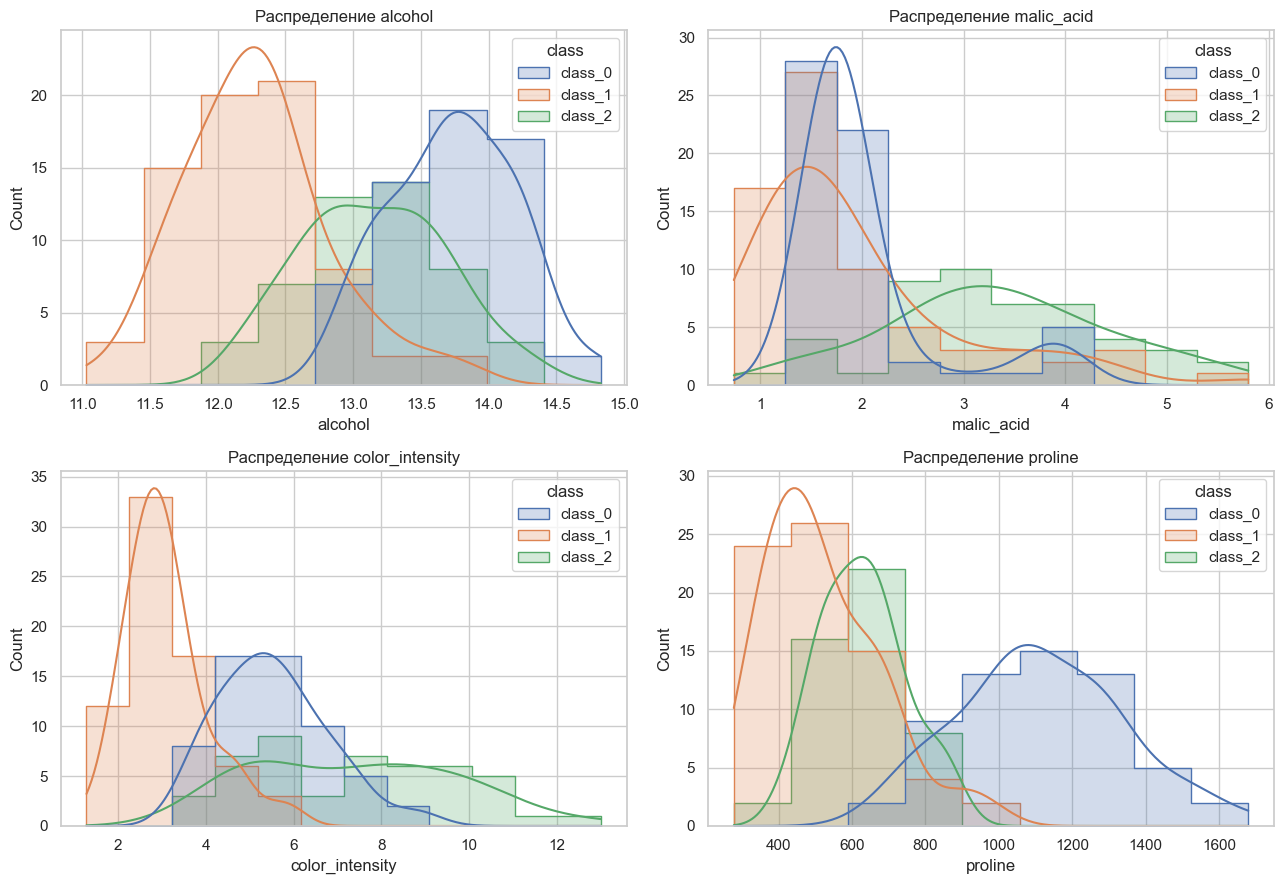

In [3]:
columns = ["alcohol", "malic_acid", "color_intensity", "proline"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for column, axis in zip(columns, axes.ravel()):
    sns.histplot(data=data, x=column, hue="class", kde=True, element="step", ax=axis)
    axis.set_title(f"Распределение {column}")
plt.tight_layout()
plt.show()

## Сравнение классов

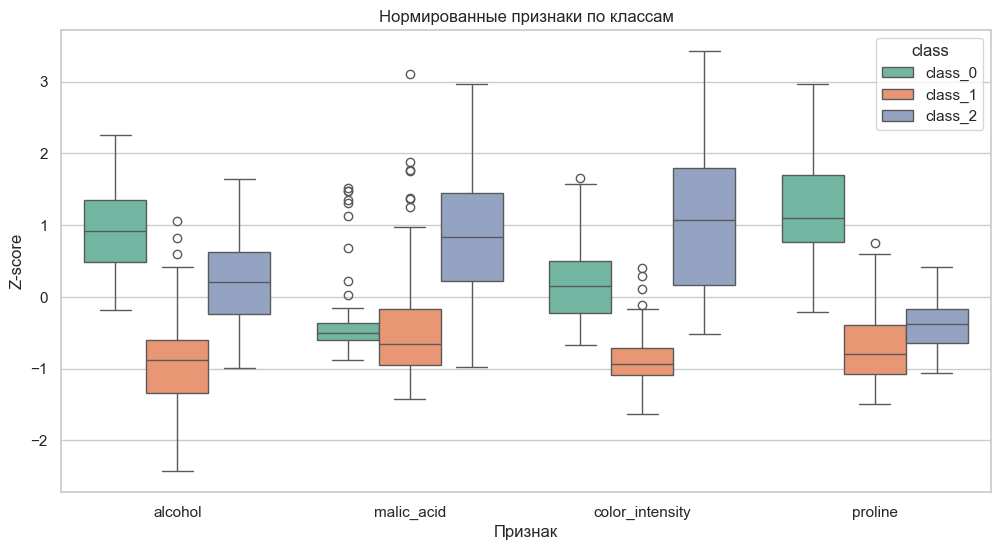

In [4]:
melted = data.melt(id_vars="class", value_vars=columns, var_name="feature", value_name="value")
normalized = melted.copy()
normalized["value"] = normalized.groupby("feature")["value"].transform(
    lambda series: (series - series.mean()) / series.std()
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=normalized, x="feature", y="value", hue="class", palette="Set2")
plt.title("Нормированные признаки по классам")
plt.xlabel("Признак")
plt.ylabel("Z-score")
plt.show()

## Связи и корреляции

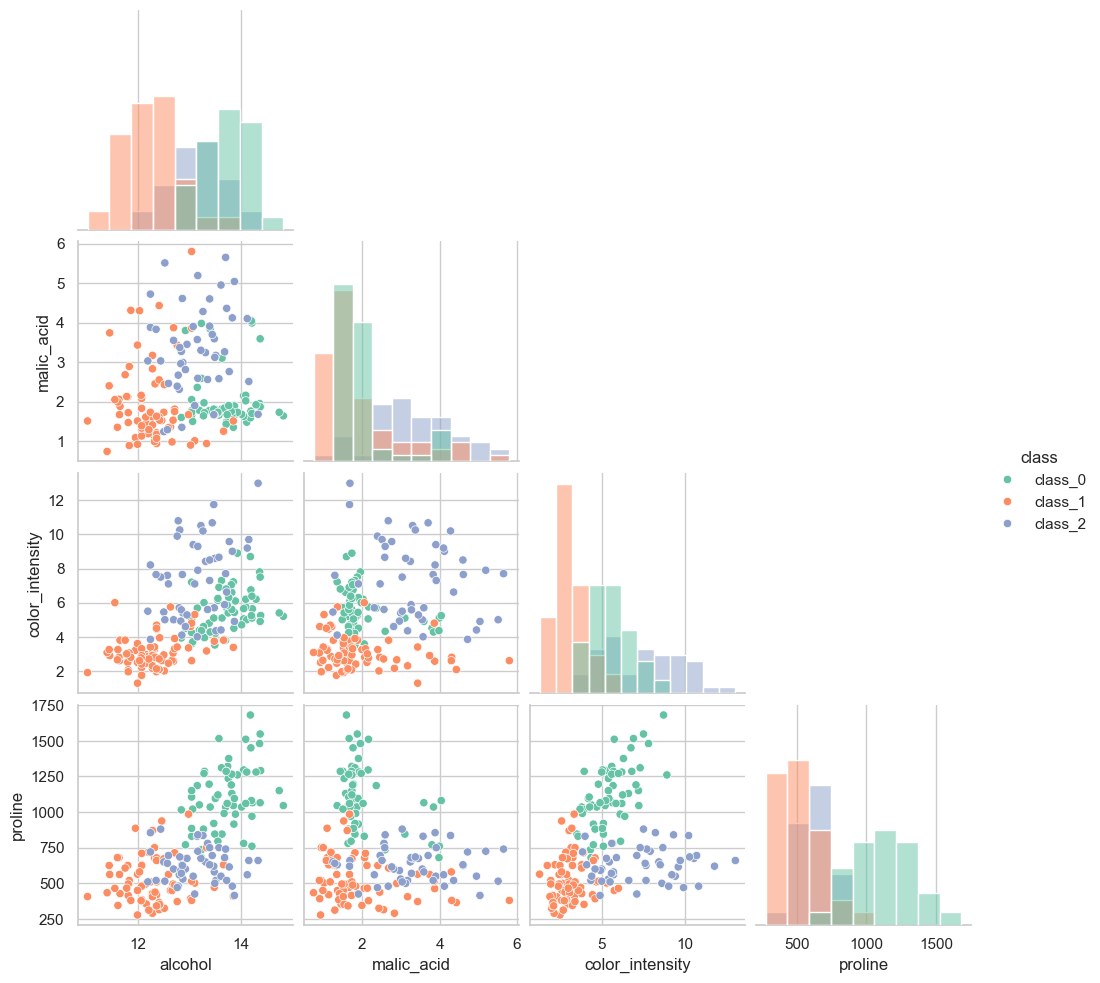

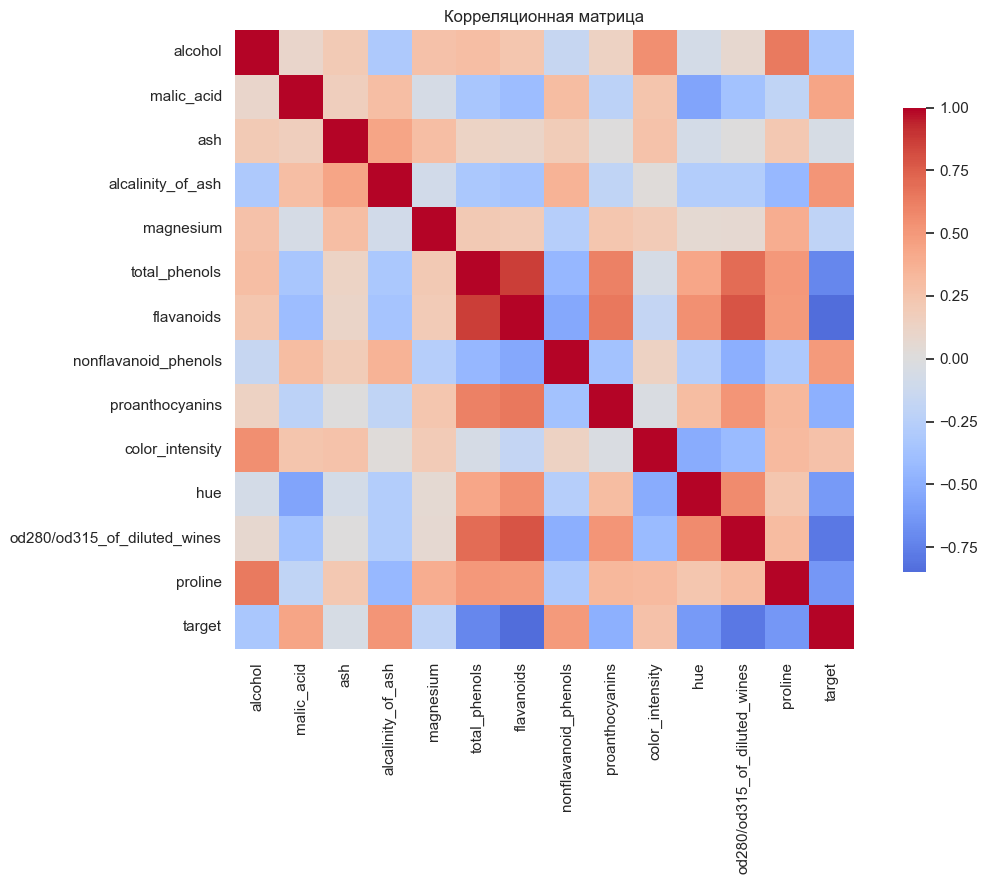

In [5]:
sns.pairplot(data, vars=columns, hue="class", corner=True, diag_kind="hist", palette="Set2")
plt.show()

plt.figure(figsize=(12, 9))
sns.heatmap(data.drop(columns="class").corr(), cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.75})
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

## Вывод

Визуализация помогает обнаружить асимметрию, выбросы, различия между классами и коррелирующие признаки. Эти наблюдения определяют дальнейшую предобработку и выбор модели.

## Расширенный визуальный EDA

In [6]:
import numpy as np

### Контроль качества и уникальности

In [7]:
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique": data.nunique(),
    "duplicates_total": data.duplicated().sum(),
})
quality

,dtype,missing,unique,duplicates_total
alcohol,float64,0,126,0
malic_acid,float64,0,133,0
ash,float64,0,79,0
alcalinity_of_ash,float64,0,63,0
magnesium,float64,0,53,0
total_phenols,float64,0,97,0
flavanoids,float64,0,132,0
nonflavanoid_phenols,float64,0,39,0
proanthocyanins,float64,0,101,0
color_intensity,float64,0,132,0


### Баланс классов

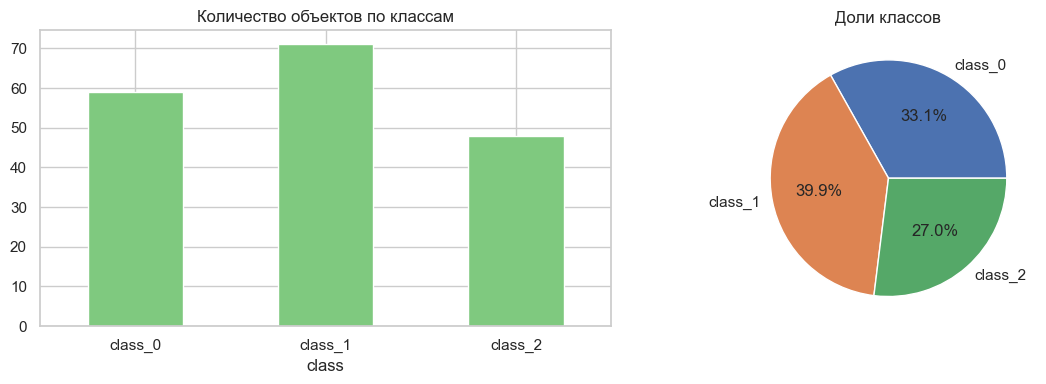

In [8]:
class_counts = data["class"].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot.bar(ax=axes[0], color="#7fc97f")
axes[0].set_title("Количество объектов по классам")
axes[0].tick_params(axis="x", rotation=0)
class_counts.plot.pie(ax=axes[1], autopct="%1.1f%%", ylabel="")
axes[1].set_title("Доли классов")
plt.tight_layout()
plt.show()

### Асимметрия распределений

,skewness,kurtosis
magnesium,1.098191,2.104991
malic_acid,1.039651,0.299207
color_intensity,0.868585,0.381522
proline,0.767822,-0.248403
proanthocyanins,0.517137,0.554649
nonflavanoid_phenols,0.450151,-0.637191
od280/od315_of_diluted_wines,-0.307285,-1.086435
alcalinity_of_ash,0.213047,0.487942
ash,-0.176699,1.143978
total_phenols,0.086639,-0.835627


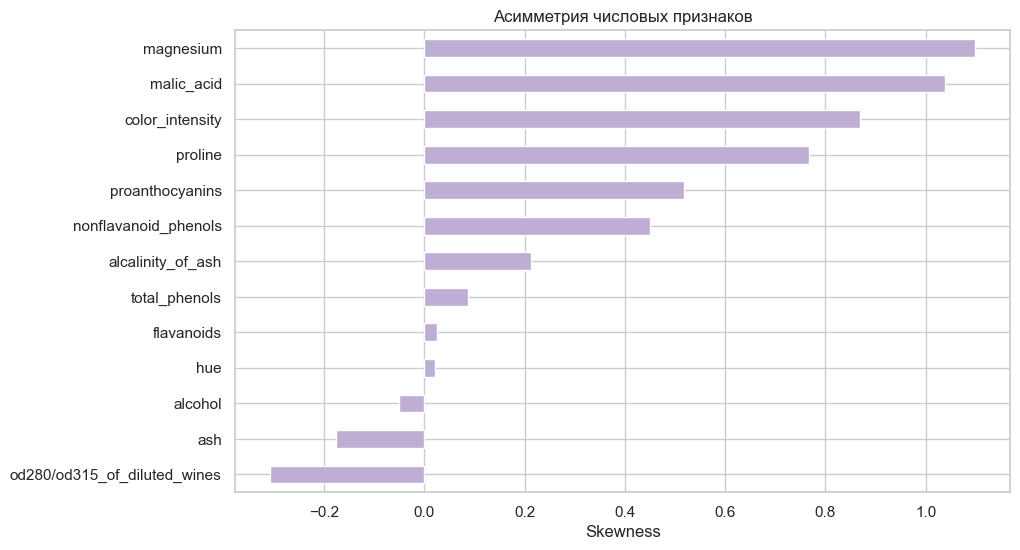

In [9]:
numeric_columns = data.select_dtypes(include="number").columns.drop("target")
distribution_summary = pd.DataFrame({
    "skewness": data[numeric_columns].skew(),
    "kurtosis": data[numeric_columns].kurtosis(),
}).sort_values("skewness", key=np.abs, ascending=False)
display(distribution_summary)

distribution_summary["skewness"].sort_values().plot.barh(figsize=(10, 6), color="#beaed4")
plt.title("Асимметрия числовых признаков")
plt.xlabel("Skewness")
plt.show()

### Выбросы по правилу IQR

,feature,outliers,share
3,alcalinity_of_ash,4,0.022472
4,magnesium,4,0.022472
9,color_intensity,4,0.022472
1,malic_acid,3,0.016854
2,ash,3,0.016854
8,proanthocyanins,2,0.011236
10,hue,1,0.005618
0,alcohol,0,0.000000
5,total_phenols,0,0.000000
6,flavanoids,0,0.000000


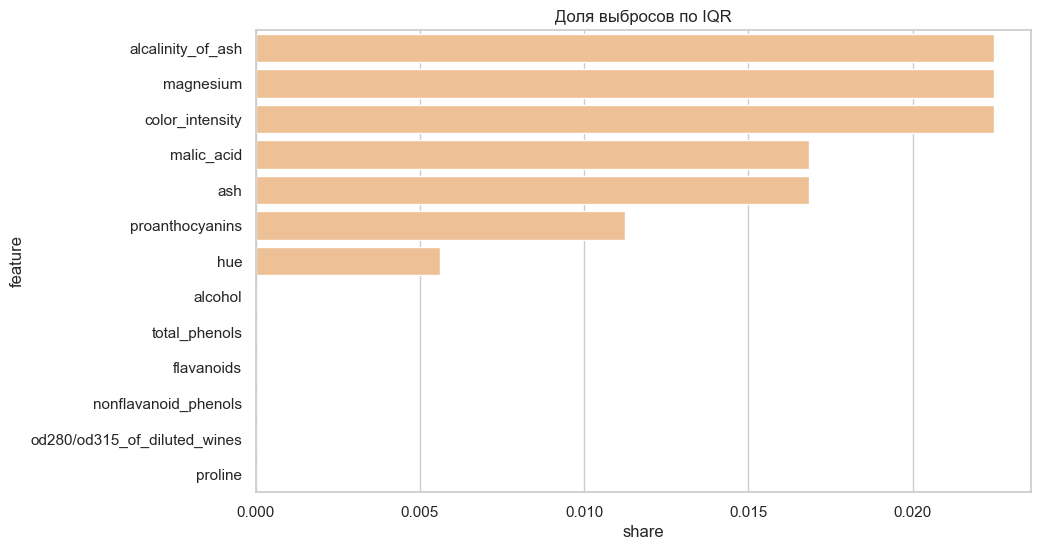

In [10]:
outlier_rows = []
for column in numeric_columns:
    first_quartile = data[column].quantile(0.25)
    third_quartile = data[column].quantile(0.75)
    iqr = third_quartile - first_quartile
    outliers = ((data[column] < first_quartile - 1.5 * iqr) | (data[column] > third_quartile + 1.5 * iqr)).sum()
    outlier_rows.append({"feature": column, "outliers": int(outliers), "share": outliers / len(data)})

outlier_summary = pd.DataFrame(outlier_rows).sort_values("share", ascending=False)
display(outlier_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=outlier_summary, x="share", y="feature", color="#fdc086")
plt.title("Доля выбросов по IQR")
plt.show()

### Профили классов после стандартизации

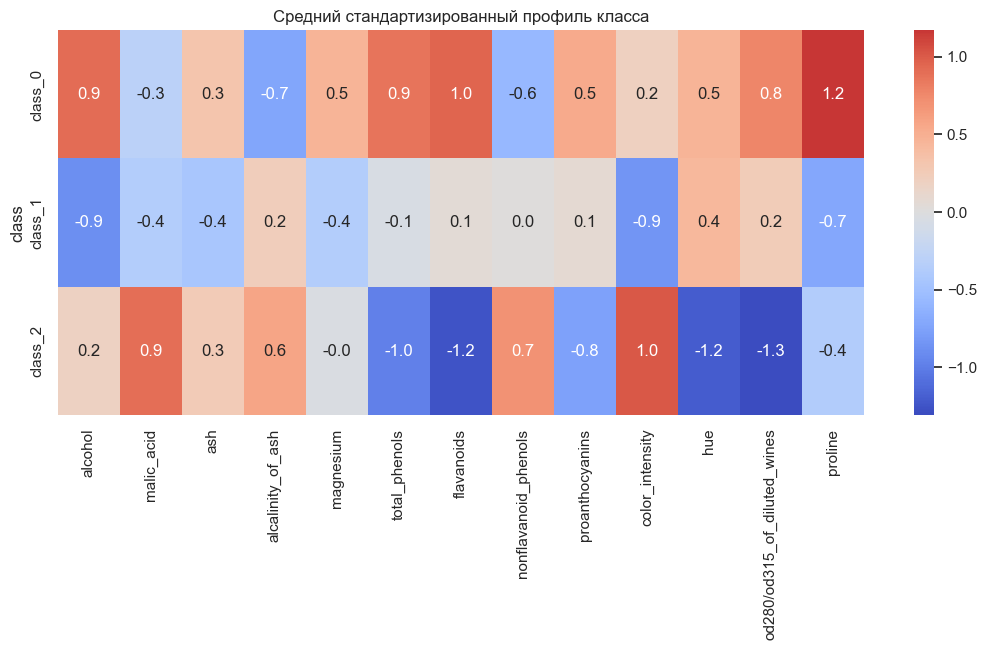

In [11]:
standardized = data[numeric_columns].apply(lambda series: (series - series.mean()) / series.std())
standardized["class"] = data["class"]
class_profiles = standardized.groupby("class").mean()

plt.figure(figsize=(13, 5))
sns.heatmap(class_profiles, cmap="coolwarm", center=0, annot=True, fmt=".1f")
plt.title("Средний стандартизированный профиль класса")
plt.show()

### Многомерная связь ключевых признаков

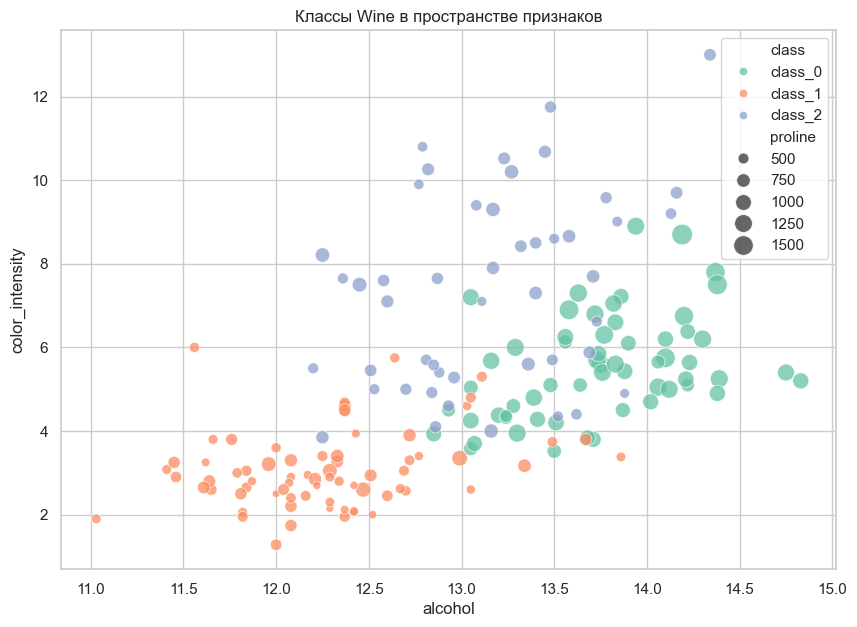

In [12]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=data,
    x="alcohol",
    y="color_intensity",
    hue="class",
    size="proline",
    sizes=(30, 220),
    alpha=0.75,
    palette="Set2",
)
plt.title("Классы Wine в пространстве признаков")
plt.show()

### Корреляции без целевого признака

In [13]:
correlation_pairs = (
    data[numeric_columns]
    .corr()
    .where(np.triu(np.ones((len(numeric_columns), len(numeric_columns))), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
correlation_pairs["absolute"] = correlation_pairs["correlation"].abs()
correlation_pairs.sort_values("absolute", ascending=False).head(15)

,feature_1,feature_2,correlation,absolute
50,total_phenols,flavanoids,0.864564,0.864564
61,flavanoids,od280/od315_of_diluted_wines,0.787194,0.787194
55,total_phenols,od280/od315_of_diluted_wines,0.699949,0.699949
58,flavanoids,proanthocyanins,0.652692,0.652692
11,alcohol,proline,0.643720,0.643720
52,total_phenols,proanthocyanins,0.612413,0.612413
75,hue,od280/od315_of_diluted_wines,0.565468,0.565468
20,malic_acid,hue,-0.561296,0.561296
8,alcohol,color_intensity,0.546364,0.546364
60,flavanoids,hue,0.543479,0.543479


### Итог расширенного анализа

EDA должен отвечать не только на вопрос «как выглядит распределение», но и выявлять пропуски, дубликаты, дисбаланс, асимметрию, выбросы, групповые различия и мультиколлинеарность. Результаты определяют необходимость масштабирования, преобразований и отбора признаков.